In [4]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm/examples/logs/1gpu_bs512_prompts300'
BASELINE_DATA_PATH = '/root/workspace/vllm-org/vllm/examples/logs/1gpu'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [2]:
def get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        if baseline_policy == 'full_mem':
            filename = f'{DATA_PATH}/test_{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        else:    
            filename = f'{DATA_PATH}/test_{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_swap_{store_cache_layer}.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean TTFT' in line:
                    mean_ttft_.append(float(line.split()[-1]))
                if 'P99 TTFT' in line:
                    p99_ttft_.append(float(line.split()[-1]))    
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_ttft.append(np.mean(mean_ttft_))
        p99_ttft.append(np.mean(p99_ttft_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [5]:
def get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy):
    if baseline_policy == 'full_mem':
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0_1gpu.log'
        filename = f'{DATA_PATH}/test_{model_name}_client_0.9_{req_rate}_{total_reqs}_swap_1.0.log'
    else:    
        filename = f'{BASELINE_DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_reqs}_{baseline_policy}_1.0_1gpu.log'

    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft.append(float(line.split()[-1]))  
            if 'P99 TTFT' in line:
                p99_ttft.append(float(line.split()[-1]))      
            if 'Mean ITL' in line:
                mean_itl.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl.append(float(line.split()[-1]))        
        
    return np.mean(output_tokens_tgt), np.mean(reqs_tgt), np.mean(mean_tpot_), np.mean(p99_tpot_), np.mean(mean_ttft), np.mean(p99_ttft), np.mean(mean_itl), np.mean(p99_itl)         

In [6]:
# plot throughput
def plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [7]:
# 绘制一张大图，将不同req_rate的结果放在一张图上, 6个指标, 这张大图包含6个子图，legend放在右上角
def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(18, 2.5), dpi=120)
    axes = [fig.add_subplot(1, 6, i+1) for i in range(6)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='out_toks', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='reqs', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_tpot_imps[i], label='avg_tpot', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='p99_tpot', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_ttft_imps[i], label='avg_ttft', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_ttft_imps[i], label='p99_ttft', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_itl_imps[i], label='avg_itl', linestyle=linestyles[2], marker=markers[6], color=plt.cm.Dark2(6/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='p99_itl', linestyle=linestyles[3], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5)
        ax.set_xlabel('Cache layers(%)')
        if i == 0 : ax.set_ylabel('Improvement(%)')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        # 除了第一个子图，其他子图的y轴不显示
        # if i != 0: ax.set_yticklabels([])
        # ax.set_ylim(min(min(mean_output_tokens_imps[i]), min(mean_reqs_imps[i]), min(mean_mean_tpot_imps[i]), min(mean_p99_tpot_imps[i]), min(mean_mean_itl_imps[i]), min(mean_p99_itl_imps[i]))*0.8, max(max(mean_output_tokens_imps[i]), max(mean_reqs_imps[i]), max(mean_mean_tpot_imps[i]), max(mean_p99_tpot_imps[i]), max(mean_mean_itl_imps[i]), max(mean_p99_itl_imps[i]))*1.4)
        # ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))
        # ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        # ax.set_ylim(-10, 80)
        # x轴标签显示数字乘以100
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        ax.set_title(f'{req_rates[i]} reqs/s')
    # legend 放在右上角
    axes[-1].legend(bbox_to_anchor=(1.4, 1.0), loc='upper right', ncol=3, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()

In [8]:
def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(6, 2.3), dpi=120)
    axes = [fig.add_subplot(1, 2, i+1) for i in range(2)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='Token Tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='Req Tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_tpot_imps[i], label='Mean TPOT', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_ttft_imps[i], label='Mean TTFT', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_ttft_imps[i], label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
        # ax.plot(store_cache_layers, mean_mean_itl_imps[i], label='Mean ITL', linestyle=linestyles[2], marker=markers[6], color=plt.cm.Dark2(6/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='P99 ITL', linestyle=linestyles[3], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5)
        ax.set_xlabel('Cache layers (%)')
        if i == 0 : ax.set_ylabel('Improvement (%)')
        elif i==1:
            # parse the legend label and remove the legend of the ax
            handles, labels = ax.get_legend_handles_labels()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        ax.set_xticks(store_cache_layers)
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        ax.set_ylim(-300, 200)
        ax.yaxis.set_major_locator(plt.MultipleLocator(100))
    fig.legend(handles, labels,loc=(0.1,0.86), ncol=8, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.savefig(f'./pdf/{baseline_policy}_1gpu.pdf', bbox_inches='tight')
    plt.show()

In [9]:
def plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2.3), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(req_rates, mean_output_tokens_imps, label='Token Tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
    ax.plot(req_rates, mean_reqs_imps, label='Req Tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
    # ax.plot(req_rates, mean_mean_tpot_imps, label='Mean TPOT', linestyle=linestyles[2], marker=markers[2], color=plt.cm.Dark2(2/6), markersize=5)
    ax.plot(req_rates, mean_p99_tpot_imps, label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
    # ax.plot(req_rates, mean_mean_ttft_imps, label='Mean TTFT', linestyle=linestyles[0], marker=markers[4], color=plt.cm.Dark2(4/6), markersize=5)
    ax.plot(req_rates, mean_p99_ttft_imps, label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
    # ax.plot(req_rates, mean_mean_itl_imps, label='Mean ITL', linestyle=linestyles[0], marker=markers[6], color=plt.cm.Dark2(6/6), markersize=5)
    ax.plot(req_rates, mean_p99_itl_imps, label='P99 ITL', linestyle=linestyles[1], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5, markerfacecolor='none')
    ax.set_xlabel('Req rate (reqs/s)')
    ax.set_ylabel('Improvement (%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    # if baseline_policy == 'full_mem': ax.yaxis.set_major_locator(plt.MultipleLocator(40))
    # else: ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.set_ylim(min(min(mean_output_tokens_imps), min(mean_reqs_imps), min(mean_mean_tpot_imps), min(mean_p99_tpot_imps), min(mean_mean_itl_imps), min(mean_p99_itl_imps))*1.4, max(max(mean_output_tokens_imps), max(mean_reqs_imps), max(mean_mean_tpot_imps), max(mean_p99_tpot_imps), max(mean_mean_itl_imps), max(mean_p99_itl_imps))*1.4)
    # ax.legend( bbox_to_anchor=(0.02, 1.1), loc='upper left', ncol=4, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    # plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc=(0.1,0.82), ncol=3, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.show()

In [10]:
# 绘制柱状图，对比swap和recompute的性能提升
def plot_bar(swap_imps, recompute_imps, full_mem_imps):
    # print(f'swap_imps: {swap_imps}, recompute_imps: {recompute_imps}')
    fig = plt.figure(figsize=(6, 2.5), dpi=120)
    ax = fig.add_subplot(111)
    bar_width = 0.25
    bar1 = ax.bar(np.arange(8), swap_imps, bar_width, label='swap', color='skyblue', hatch=hatches[0])
    bar2 = ax.bar(np.arange(8)+bar_width, recompute_imps, bar_width, label='recompute', color='lightcoral', hatch=hatches[1])
    bar3 = ax.bar(np.arange(8)+bar_width*2, full_mem_imps, bar_width, label='full_mem', color='lightgreen', hatch=hatches[2])
    # 将数值标注在柱状图上
    for x, y in zip(np.arange(8), swap_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width, recompute_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    for x, y in zip(np.arange(8)+bar_width*2, full_mem_imps):
        if y >= 0: ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', rotation=0, fontsize=8)
        else: ax.text(x, y, f'{y:.0f}', ha='center', va='top', rotation=0, fontsize=8)
    ax.set_xticks(np.arange(8)+bar_width)
    ax.set_xticklabels(['out_toks', 'reqs', 'avg_tpot', 'p99_tpot', 'avg_ttft', 'p99_ttft', 'avg_itl', 'p99_itl'], rotation=0)
    ax.set_ylabel('Improvement(%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_major_locator(plt.MultipleLocator(30))
    ax.set_ylim(min(min(swap_imps), min(recompute_imps), min(full_mem_imps))*1.4, max(max(swap_imps), max(recompute_imps), max(full_mem_imps))*1.4)

    ax.grid(linestyle='-.', alpha=0.3, axis='y')
    # ax.legend(bbox_to_anchor=(0.01, 1.05), loc='upper left', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    ax.legend(loc='best', ncol=1, frameon=False, columnspacing=0.2, labelspacing=0.2, handlelength=1.2, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()    

In [15]:
def plot_all_figs(model_name, gpu_utilization):
    model_name = model_name.replace('/', '_')
    req_rates = [100, 200, 300]
    total_reqs = 300
    store_cache_layers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    baseline_policies = ['swap', 'recompute', 'full_mem']
    swap_imps, recompute_imps, full_mem_imps = [], [], []
    for baseline_policy in baseline_policies:
        print(f'baseline_policy---------------------->: {baseline_policy}')
        mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps = [], [], [], [], [], [], [], []
        output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all = [], [], [], [], [], [], [], []
        for req_rate in req_rates:
            output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
            mean_output_tokens_imps.append(np.mean(output_tokens_imps))
            mean_reqs_imps.append(np.mean(reqs_imps))
            mean_mean_tpot_imps.append(np.mean(mean_tpot_imps))
            mean_p99_tpot_imps.append(np.mean(p99_tpot_imps))
            mean_mean_ttft_imps.append(np.mean(mean_ttft_imps))
            mean_p99_ttft_imps.append(np.mean(p99_ttft_imps))
            mean_mean_itl_imps.append(np.mean(mean_itl_imps))
            mean_p99_itl_imps.append(np.mean(p99_itl_imps))

            output_tokens_imps_all.append(output_tokens_imps)
            reqs_imps_all.append(reqs_imps)
            mean_tpot_imps_all.append(mean_tpot_imps)
            p99_tpot_imps_all.append(p99_tpot_imps)
            mean_ttft_imps_all.append(mean_ttft_imps)
            p99_ttft_imps_all.append(p99_ttft_imps)
            mean_itl_imps_all.append(mean_itl_imps)
            p99_itl_imps_all.append(p99_itl_imps)

        plot_big_fig(baseline_policy, req_rates, store_cache_layers, output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all)
        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')
        plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps)

        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')

        print(f'mean_p99_tpot_imps: {mean_p99_tpot_imps}')
        base_imps = []
        base_imps.append(np.mean(mean_output_tokens_imps))
        base_imps.append(np.mean(mean_reqs_imps))
        base_imps.append(np.mean(mean_mean_tpot_imps))
        base_imps.append(np.mean(mean_p99_tpot_imps))
        base_imps.append(np.mean(mean_mean_ttft_imps))
        base_imps.append(np.mean(mean_p99_ttft_imps))
        base_imps.append(np.mean(mean_mean_itl_imps))
        base_imps.append(np.mean(mean_p99_itl_imps))
        if baseline_policy == 'swap':
            swap_imps = base_imps
        if baseline_policy == 'recompute':
            recompute_imps = base_imps 
        if baseline_policy == 'full_mem':
            full_mem_imps = base_imps    

    plot_bar(swap_imps, recompute_imps, full_mem_imps)       

baseline_policy---------------------->: swap
mean_output_tokens_imps: [[145.84476841774955, 147.42368170701943, 105.95603946785141, 93.98219862430328, 73.68046181968509, 58.354543235825886, 44.50543156133106, 31.662441288831534, 24.801390639086314], [165.19628875490747, 145.09743134419784, 111.64563115223692, 91.04331025999049, 70.42858878938111, 36.33939886956327, 48.01330334046777, 30.808740919676463, 18.83474245238796], [149.01037699329427, 149.23764688253144, 124.64754436133414, 112.82701264969216, 84.87281627352304, 70.03533921904072, 57.23330128245152, 42.2035189370762, 16.80423571134226]]


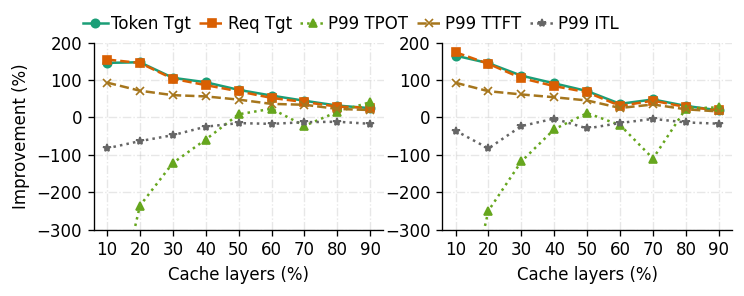

mean_output_tokens_imps: 83.35148833165847, mean_reqs_imps: 81.03478838450349, mean_mean_tpot_imps: -78.93900384553486, mean_p99_tpot_imps: -125.41528514402371, mean_mean_ttft_imps: 52.728582816137894, mean_p99_ttft_imps: 48.76189482088895, mean_mean_itl_imps: -27.403239507129125, mean_p99_itl_imps: -24.59564870147727
mean_output_tokens_imps: [80.69010630685372, 79.71193732031216, 89.65242136780952]


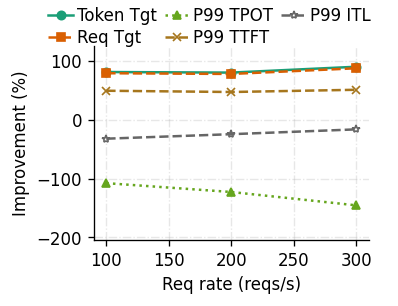

mean_output_tokens_imps: 83.35148833165847, mean_reqs_imps: 81.03478838450349, mean_mean_tpot_imps: -78.93900384553486, mean_p99_tpot_imps: -125.41528514402371, mean_mean_ttft_imps: 52.728582816137894, mean_p99_ttft_imps: 48.76189482088895, mean_mean_itl_imps: -27.403239507129125, mean_p99_itl_imps: -24.59564870147727
mean_p99_tpot_imps: [-107.86135557254585, -122.86451617843711, -145.51998368108818]
baseline_policy---------------------->: recompute
mean_output_tokens_imps: [[161.32477048676924, 163.00310253179302, 118.92438505278542, 106.19659250945055, 84.61652495261492, 68.32558582788891, 53.6044430796599, 39.952773748133716, 32.65970626542001], [179.744557056075, 158.54310665083008, 123.25619116885291, 101.52365803504621, 79.77804404585623, 43.81877259717768, 56.13308985501179, 37.98471109622799, 25.35383713811813], [166.45411981015093, 166.69731047162955, 140.3846153846154, 127.7360285628768, 97.8235772010091, 81.94670115876342, 68.24785137041948, 52.16519861461495, 24.98663787574

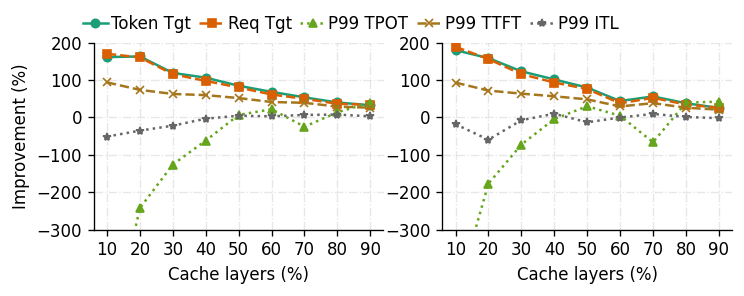

mean_output_tokens_imps: 94.85873676101978, mean_reqs_imps: 91.92344483948487, mean_mean_tpot_imps: -63.04477802698313, mean_p99_tpot_imps: -102.81276933763168, mean_mean_ttft_imps: 56.02469378627642, mean_p99_ttft_imps: 51.90624837122116, mean_mean_itl_imps: -20.302558509436803, mean_p99_itl_imps: -7.010368303886466
mean_output_tokens_imps: [92.06754271716842, 89.57066307146623, 102.93800449442475]


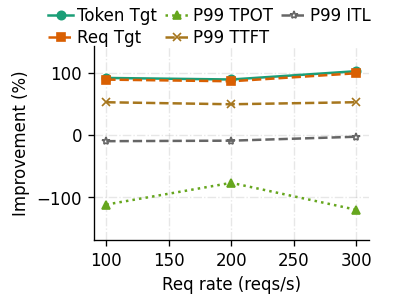

mean_output_tokens_imps: 94.85873676101978, mean_reqs_imps: 91.92344483948487, mean_mean_tpot_imps: -63.04477802698313, mean_p99_tpot_imps: -102.81276933763168, mean_mean_ttft_imps: 56.02469378627642, mean_p99_ttft_imps: 51.90624837122116, mean_mean_itl_imps: -20.302558509436803, mean_p99_itl_imps: -7.010368303886466
mean_p99_tpot_imps: [-111.6258185495261, -76.70747654968643, -120.10501291368251]
baseline_policy---------------------->: full_mem
mean_output_tokens_imps: [[21.28534077816184, 10.842639368962157, 21.647611450855266, 15.860143578835412, 17.506425596029434, 14.339049898076746, 9.620668261987063, 3.9018877957989924, 4.92665957635381], [13.572384320965886, 13.09525044342332, -0.00933522803887934, 7.493076372537823, -1.1067431463867556, 6.873839579292376, 1.8535613894968317, 2.109761536785976, -4.874026283853168], [24.46099209531448, 20.014892885783013, 20.09623095429029, 26.663993584603062, 18.611524802382853, 16.935502348493532, 16.609004467865738, 10.331080307022576, 7.1222

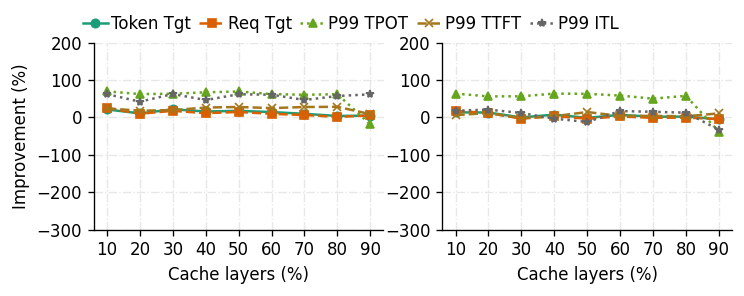

mean_output_tokens_imps: 11.843838998485937, mean_reqs_imps: 9.798521945779433, mean_mean_tpot_imps: 24.737027871261834, mean_p99_tpot_imps: 50.41999984869525, mean_mean_ttft_imps: -1.5861651072501115, mean_p99_ttft_imps: 13.7616897249285, mean_mean_itl_imps: 7.22829398336394, mean_p99_itl_imps: 36.784912668769906
mean_output_tokens_imps: [13.325602922784526, 4.334196553802601, 17.87171751887069]


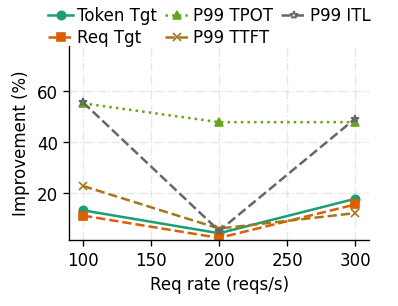

mean_output_tokens_imps: 11.843838998485937, mean_reqs_imps: 9.798521945779433, mean_mean_tpot_imps: 24.737027871261834, mean_p99_tpot_imps: 50.41999984869525, mean_mean_ttft_imps: -1.5861651072501115, mean_p99_ttft_imps: 13.7616897249285, mean_mean_itl_imps: 7.22829398336394, mean_p99_itl_imps: 36.784912668769906
mean_p99_tpot_imps: [55.3459290511771, 47.946210393289135, 47.96786010161949]


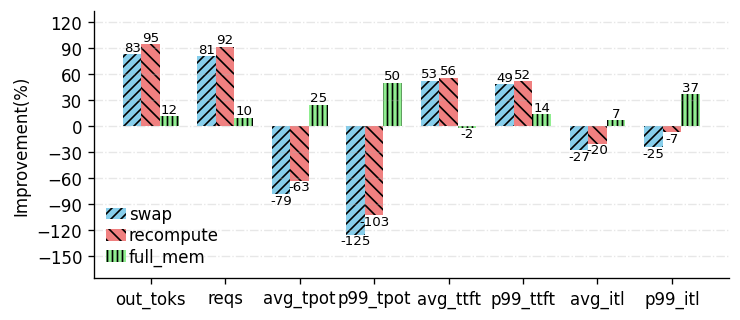

In [16]:
model_name = 'meta-llama/Llama-2-13b-hf'
gpu_utilization = 0.4
plot_all_figs(model_name, gpu_utilization)